In [1]:
1+2

3

In [2]:

!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("All imports done!")

All imports done!


In [3]:
orders = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\orders.csv')
order_products = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\order_products__prior.csv')
products = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\products.csv')
pincode_df  = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\5c2f62fe-5afa-4119-a499-fec9d604d5bd.csv')



In [4]:
pincode_df.columns

Index(['circlename', 'regionname', 'divisionname', 'officename', 'pincode',
       'officetype', 'delivery', 'district', 'statename', 'latitude',
       'longitude'],
      dtype='str')

In [5]:
pincode_df[pincode_df['regionname'] =='Ahmedabad HQ Region']

,circlename,regionname,divisionname,officename,pincode,officetype,delivery,district,statename,latitude,longitude
9793,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Bakrol BO,382210,BO,Delivery,AHMADABAD,GUJARAT,23.029651,72.626689
9794,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Kubadthal BO,382430,BO,Delivery,AHMADABAD,GUJARAT,23.033567,72.758744
9795,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Kujad BO,382430,BO,Delivery,AHMADABAD,GUJARAT,23.060085,72.711379
9796,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Pardhol BO,382330,BO,Delivery,AHMADABAD,GUJARAT,23.095606,72.726643
9797,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Girmatha BO,382425,BO,Delivery,AHMADABAD,GUJARAT,22.877825,72.551355
...,...,...,...,...,...,...,...,...,...,...,...
161712,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Lusadia SO,383251,PO,Delivery,ARVALLI,GUJARAT,23.6899840,73.4652630
161713,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Malpur SO,383345,PO,Delivery,ARVALLI,GUJARAT,23.3589444,73.4647778
161714,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Radhiwad SO,383270,PO,Delivery,SABAR KANTHA,GUJARAT,23.7312360,72.9841960
161715,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Takatuka SO,383246,PO,Delivery,ARVALLI,GUJARAT,23.7985000,73.2901944


In [6]:
# search for anything related to ahmedabad in any column
mask = pincode_df.apply(
    lambda col: col.astype(str).str.upper().str.contains('AHMEDABAD', na=False)
).any(axis=1)

print(f"Rows mentioning Ahmedabad anywhere: {mask.sum()}")
print(pincode_df[mask][['officename','pincode','district','statename']].head(20))

Rows mentioning Ahmedabad anywhere: 2269
           officename  pincode      district statename
9793        Bakrol BO   382210     AHMADABAD   GUJARAT
9794     Kubadthal BO   382430     AHMADABAD   GUJARAT
9795         Kujad BO   382430     AHMADABAD   GUJARAT
9796       Pardhol BO   382330     AHMADABAD   GUJARAT
9797      Girmatha BO   382425     AHMADABAD   GUJARAT
9798         Vasai BO   382425     AHMADABAD   GUJARAT
9799      Geratpur BO   382435     AHMADABAD   GUJARAT
9800     Sagrosana BO   385001  BANAS KANTHA   GUJARAT
9801      Hasanpur BO   385001  BANAS KANTHA   GUJARAT
9802       Jalotra BO   385001  BANAS KANTHA   GUJARAT
9803        Sangra BO   385001  BANAS KANTHA   GUJARAT
9804       Karjoda BO   385001  BANAS KANTHA   GUJARAT
9805      Dhagadia BO   385110  BANAS KANTHA   GUJARAT
9806        Chatra BO   385320  BANAS KANTHA   GUJARAT
9807     Garambadi BO   385320  BANAS KANTHA   GUJARAT
9808     Jasanwada BO   385320  BANAS KANTHA   GUJARAT
9809        Soneth BO   

In [7]:
import pandas as pd
import numpy as np


ahmedabad_df = pincode_df[
    pincode_df['district'].str.upper().str.contains('AHMADABAD', na=False)
].copy()

ahmedabad_df = ahmedabad_df.dropna(subset=['latitude', 'longitude'])
ahmedabad_df = ahmedabad_df.drop_duplicates(subset='pincode')

print(f"Total Ahmedabad pincodes found: {ahmedabad_df.shape[0]}")
print(ahmedabad_df[['pincode','officename','district','latitude','longitude']].head(15))

Total Ahmedabad pincodes found: 81
      pincode    officename   district    latitude   longitude
9793   382210     Bakrol BO  AHMADABAD   23.029651   72.626689
9794   382430  Kubadthal BO  AHMADABAD   23.033567   72.758744
9796   382330    Pardhol BO  AHMADABAD   23.095606   72.726643
9797   382425   Girmatha BO  AHMADABAD   22.877825   72.551355
9799   382435   Geratpur BO  AHMADABAD   22.920627   72.648634
9868   382225     Vautha BO  AHMADABAD  22.6700000  72.5400000
9872   382220     Adroda BO  AHMADABAD  22.8300000  72.3100000
9874   382463      Ambli BO  AHMADABAD  23.0300000  72.4800000
9877   382260  Chandisar BO  AHMADABAD  22.8000000  72.4900000
9881   382460     Jaliya BO  AHMADABAD  22.7300000  72.4800000
9885   382465   Buranpur BO  AHMADABAD  22.3900000  72.2300000
9890   382145   Balsasan BO  AHMADABAD  23.4200000  72.2800000
9892   382265      Virdi BO  AHMADABAD  22.6300000  72.5000000
9893   382240     Gangad BO  AHMADABAD  22.6900000  72.2800000
9895   382230     Bh

In [8]:
orders['user_id'].unique()
orders[orders['user_id']==206207]

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
3421002,2166133,206207,prior,1,6,19,NaN
3421003,1074448,206207,prior,2,0,10,1.00
3421004,1666077,206207,prior,3,2,15,23.00
3421005,2364140,206207,prior,4,6,14,4.00
3421006,2277235,206207,prior,5,3,20,30.00
3421007,1791139,206207,prior,6,4,11,8.00
3421008,85132,206207,prior,7,0,15,30.00
3421009,1060980,206207,prior,8,0,21,30.00
3421010,2099684,206207,prior,9,1,12,1.00
3421011,1357124,206207,prior,10,3,11,16.00


In [9]:
products[products['product_id']==46475]

,product_id,product_name,aisle_id,department_id
46474,46475,Chocolate Chip Cookie Dough Frozen Greek Yogur...,58,1


In [10]:
order_products[order_products['order_id']==206207]

,order_id,product_id,add_to_cart_order,reordered
1955165,206207,46475,1,1
1955166,206207,45548,2,0
1955167,206207,36923,3,1
1955168,206207,19348,4,1
1955169,206207,30958,5,0


In [11]:
print("=== Missing values in orders ===")
print(orders.isnull().sum())

print("\n=== Data types ===")
print(orders.dtypes)

print("\n=== Order stats ===")
print(f"Total orders      : {orders['order_id'].nunique():,}")
print(f"Total users       : {orders['user_id'].nunique():,}")
print(f"Total products    : {products['product_id'].nunique():,}")
print(f"Total order lines : {order_products.shape[0]:,}")

print("\n=== Days of week in data (0=Sat, 1=Sun) ===")
print(orders['order_dow'].value_counts().sort_index())

print("\n=== Hour distribution sample ===")
print(orders['order_hour_of_day'].describe())

=== Missing values in orders ===
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

=== Data types ===
order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

=== Order stats ===
Total orders      : 3,421,083
Total users       : 206,209
Total products    : 49,688
Total order lines : 32,434,489

=== Days of week in data (0=Sat, 1=Sun) ===
order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
Name: count, dtype: int64

=== Hour distribution sample ===
count   3421083.00
mean         13.45
std           4.23
min           0.00
25%          10.00
50%          13.00
7

In [12]:
# pick 10 real pincodes spread across ahmedabad
selected = ahmedabad_df[['pincode','officename','latitude','longitude']].head(10).reset_index(drop=True)

# clean office name — remove BO, SO, HO suffixes
selected = selected.rename(columns={'officename': 'area_name'})
selected['area_name'] = selected['area_name'].str.replace(
    r'\s*(S\.O|B\.O|H\.O|BO|SO|HO)$', '', regex=True
).str.strip().str.title()

print("Your 10 selected Ahmedabad pincodes:")
print(selected)
print()

# build lookup dicts
AHMEDABAD_PINCODES = selected['pincode'].tolist()
PINCODE_NAMES      = dict(zip(selected['pincode'], selected['area_name']))
PINCODE_LAT        = dict(zip(selected['pincode'], selected['latitude']))
PINCODE_LON        = dict(zip(selected['pincode'], selected['longitude']))

print("Pincodes list:", AHMEDABAD_PINCODES)
print("Names:", PINCODE_NAMES)

Your 10 selected Ahmedabad pincodes:
   pincode  area_name    latitude   longitude
0   382210     Bakrol   23.029651   72.626689
1   382430  Kubadthal   23.033567   72.758744
2   382330    Pardhol   23.095606   72.726643
3   382425   Girmatha   22.877825   72.551355
4   382435   Geratpur   22.920627   72.648634
5   382225     Vautha  22.6700000  72.5400000
6   382220     Adroda  22.8300000  72.3100000
7   382463      Ambli  23.0300000  72.4800000
8   382260  Chandisar  22.8000000  72.4900000
9   382460     Jaliya  22.7300000  72.4800000

Pincodes list: [382210, 382430, 382330, 382425, 382435, 382225, 382220, 382463, 382260, 382460]
Names: {382210: 'Bakrol', 382430: 'Kubadthal', 382330: 'Pardhol', 382425: 'Girmatha', 382435: 'Geratpur', 382225: 'Vautha', 382220: 'Adroda', 382463: 'Ambli', 382260: 'Chandisar', 382460: 'Jaliya'}


In [13]:
orders['pincode']   = orders['user_id'].apply(lambda uid: AHMEDABAD_PINCODES[uid % 10])
orders['area_name'] = orders['pincode'].map(PINCODE_NAMES)
orders['latitude']  = orders['pincode'].map(PINCODE_LAT)
orders['longitude'] = orders['pincode'].map(PINCODE_LON)

print("Sample orders with real Ahmedabad pincode:")
print(orders[['user_id','pincode','area_name','latitude','longitude']].head(10))
print(f"\nUnique pincodes assigned: {orders['pincode'].nunique()}")
print(f"Pincode distribution:\n{orders['pincode'].value_counts()}")

Sample orders with real Ahmedabad pincode:
   user_id  pincode  area_name   latitude  longitude
0        1   382430  Kubadthal  23.033567  72.758744
1        1   382430  Kubadthal  23.033567  72.758744
2        1   382430  Kubadthal  23.033567  72.758744
3        1   382430  Kubadthal  23.033567  72.758744
4        1   382430  Kubadthal  23.033567  72.758744
5        1   382430  Kubadthal  23.033567  72.758744
6        1   382430  Kubadthal  23.033567  72.758744
7        1   382430  Kubadthal  23.033567  72.758744
8        1   382430  Kubadthal  23.033567  72.758744
9        1   382430  Kubadthal  23.033567  72.758744

Unique pincodes assigned: 10
Pincode distribution:
pincode
382225    344088
382260    343758
382460    342901
382430    342777
382210    341974
382463    341851
382425    341341
382220    341162
382435    340899
382330    340332
Name: count, dtype: int64


In [14]:
df = order_products.merge(orders, on='order_id')
df = df.merge(
    products[['product_id','product_name','aisle_id','department_id']],
    on='product_id'
)

In [15]:
df[df['order_id']==206207]

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,pincode,area_name,latitude,longitude,product_name,aisle_id,department_id
1955165,206207,46475,1,1,79748,prior,15,0,13,16.00,382260,Chandisar,22.8000000,72.4900000,Chocolate Chip Cookie Dough Frozen Greek Yogur...,58,1
1955166,206207,45548,2,0,79748,prior,15,0,13,16.00,382260,Chandisar,22.8000000,72.4900000,Cheese Filled Blintzes Crepes,33,6
1955167,206207,36923,3,1,79748,prior,15,0,13,16.00,382260,Chandisar,22.8000000,72.4900000,Trop50 No Pulp Orange Juice,31,7
1955168,206207,19348,4,1,79748,prior,15,0,13,16.00,382260,Chandisar,22.8000000,72.4900000,Fat Free Milk,84,16
1955169,206207,30958,5,0,79748,prior,15,0,13,16.00,382260,Chandisar,22.8000000,72.4900000,Honey Mustard and Onion Pretzels Pieces,107,19


In [16]:
import os

path = r'F:\projectss\personal\blinkit_project\data\processed'
os.makedirs(path, exist_ok=True)

df.to_csv(os.path.join(path, 'master_df.csv'), index=False)

In [17]:
import os
print(os.getcwd())

f:\projectss\personal\blinkit_project\noteboook


In [18]:
# ── Cell 7 — build demand table (input for feature engineering) ───────

# pick top 50 products by order volume
TOP_PRODUCTS = (
    df.groupby('product_id')
    .size()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)

demand_df = (
    df[df['product_id'].isin(TOP_PRODUCTS)]
    .groupby(['product_id','product_name',
              'pincode','area_name',
              'latitude','longitude',
              'order_dow','order_hour_of_day'])
    .size()
    .reset_index(name='demand')
)

print("Demand table shape:", demand_df.shape)
print("\nSample:")
print(demand_df.head(8))
print(f"\nUnique products : {demand_df['product_id'].nunique()}")
print(f"Unique pincodes : {demand_df['pincode'].nunique()}")
print(f"Max demand      : {demand_df['demand'].max()}")
print(f"Min demand      : {demand_df['demand'].min()}")
print(f"Avg demand      : {demand_df['demand'].mean():.2f}")

demand_df.to_csv(
    r'F:\projectss\personal\blinkit_project\data\processed\demand_table.csv',
    index=False
)
print("\nSaved to data/processed/demand_table.csv")

Demand table shape: (81898, 9)

Sample:
   product_id   product_name  pincode area_name   latitude  longitude  \
0        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
1        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
2        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
3        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
4        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
5        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
6        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   
7        4605  Yellow Onions   382210    Bakrol  23.029651  72.626689   

   order_dow  order_hour_of_day  demand  
0          0                  0      10  
1          0                  1       6  
2          0                  2       4  
3          0                  3       2  
4          0                  4       1  
5          0                  5       3  
6       

In [19]:
demand_df

,product_id,product_name,pincode,area_name,latitude,longitude,order_dow,order_hour_of_day,demand
0,4605,Yellow Onions,382210,Bakrol,23.029651,72.626689,0,0,10
1,4605,Yellow Onions,382210,Bakrol,23.029651,72.626689,0,1,6
2,4605,Yellow Onions,382210,Bakrol,23.029651,72.626689,0,2,4
3,4605,Yellow Onions,382210,Bakrol,23.029651,72.626689,0,3,2
4,4605,Yellow Onions,382210,Bakrol,23.029651,72.626689,0,4,1
...,...,...,...,...,...,...,...,...,...
81893,49683,Cucumber Kirby,382463,Ambli,23.0300000,72.4800000,6,19,59
81894,49683,Cucumber Kirby,382463,Ambli,23.0300000,72.4800000,6,20,45
81895,49683,Cucumber Kirby,382463,Ambli,23.0300000,72.4800000,6,21,39
81896,49683,Cucumber Kirby,382463,Ambli,23.0300000,72.4800000,6,22,32


In [20]:
demand_df[demand_df['product_id']==30958]

,product_id,product_name,pincode,area_name,latitude,longitude,order_dow,order_hour_of_day,demand


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/plot_hourly_demand.png'

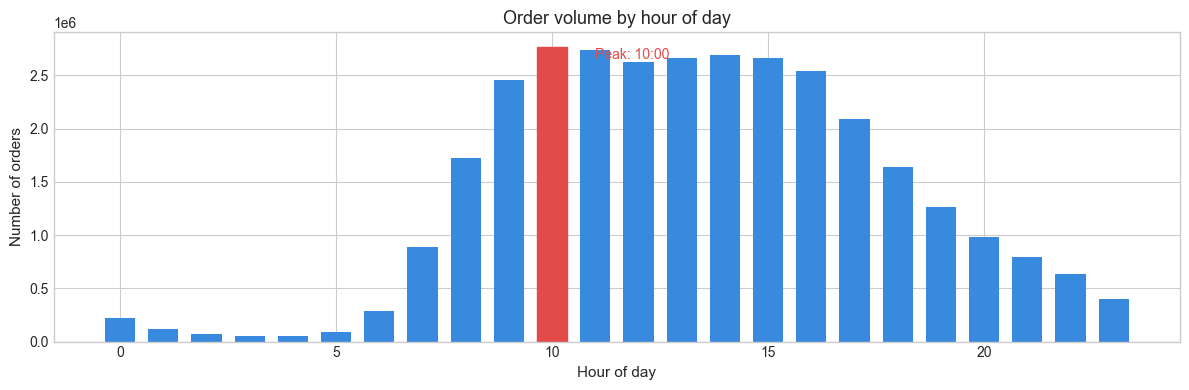

In [21]:
# ── Cell 8 — EDA Plot 1: hourly demand ───────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

hourly = df.groupby('order_hour_of_day').size().reset_index(name='orders')
peak_hour = hourly.loc[hourly['orders'].idxmax(), 'order_hour_of_day']

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(hourly['order_hour_of_day'], hourly['orders'],
              color='#378ADD', edgecolor='none', width=0.7)
bars[peak_hour].set_color('#E24B4A')
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Number of orders', fontsize=11)
ax.set_title('Order volume by hour of day', fontsize=13)
ax.annotate(f'Peak: {peak_hour}:00',
            xy=(peak_hour, hourly['orders'].max()),
            xytext=(peak_hour+1, hourly['orders'].max()*0.96),
            fontsize=10, color='#E24B4A')
plt.tight_layout()
plt.savefig('notebooks/plot_hourly_demand.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/plot_daily_demand.png'

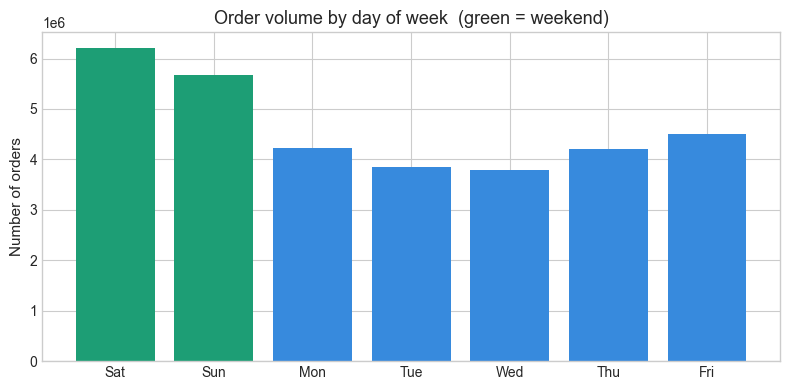

In [22]:
# ── Cell 9 — EDA Plot 2: day of week ─────────────────────────────────
DAY_NAMES = {0:'Sat',1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri'}

daily = df.groupby('order_dow').size().reset_index(name='orders')
daily['day_name'] = daily['order_dow'].map(DAY_NAMES)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1D9E75' if d in [0,1] else '#378ADD' for d in daily['order_dow']]
ax.bar(daily['day_name'], daily['orders'], color=colors, edgecolor='none')
ax.set_title('Order volume by day of week  (green = weekend)', fontsize=13)
ax.set_ylabel('Number of orders', fontsize=11)
plt.tight_layout()
plt.savefig('notebooks/plot_daily_demand.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/plot_top_products.png'

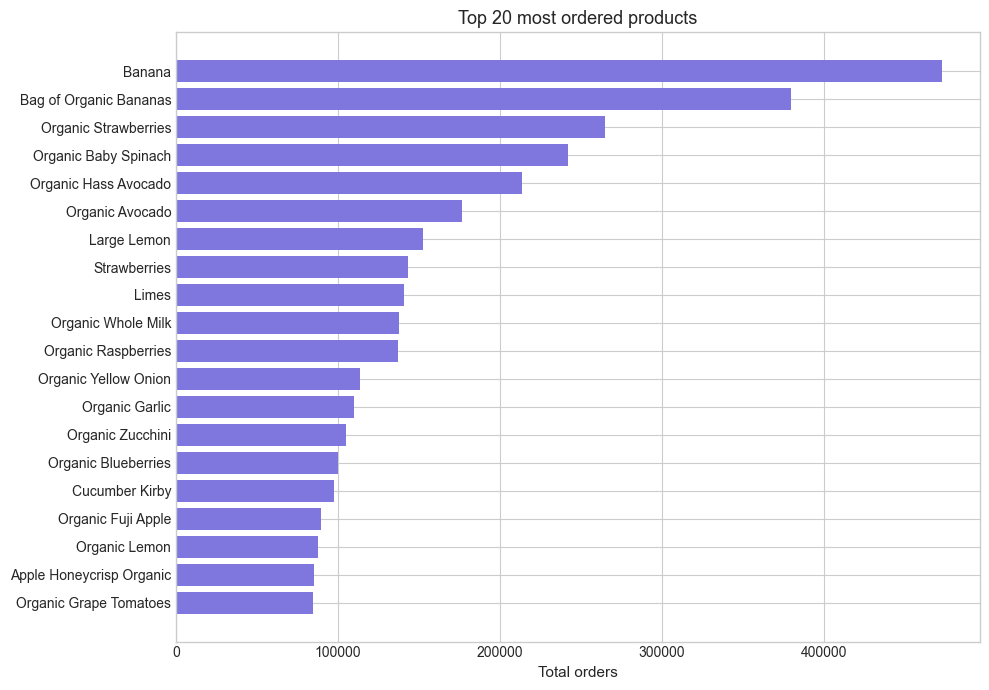

In [23]:
# ── Cell 10 — EDA Plot 3: top 20 products ────────────────────────────
top20 = (df.groupby('product_name').size()
         .sort_values(ascending=False)
         .head(20)
         .reset_index(name='count'))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['product_name'][::-1], top20['count'][::-1],
        color='#7F77DD', edgecolor='none')
ax.set_xlabel('Total orders', fontsize=11)
ax.set_title('Top 20 most ordered products', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/plot_top_products.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/plot_pincode_demand.png'

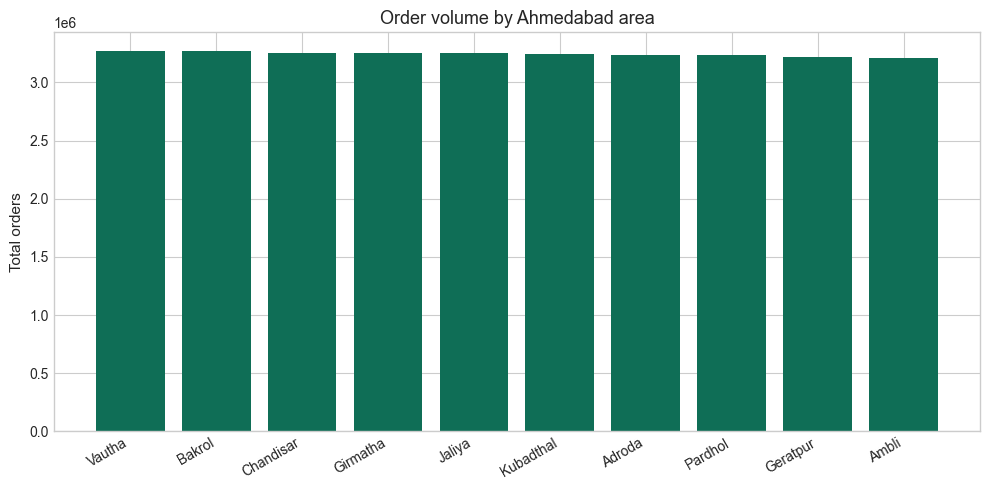

In [24]:
# ── Cell 11 — EDA Plot 4: demand by pincode ──────────────────────────
pincode_demand = (df.groupby(['pincode','area_name'])
                  .size()
                  .reset_index(name='orders')
                  .sort_values('orders', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pincode_demand['area_name'], pincode_demand['orders'],
       color='#0F6E56', edgecolor='none')
ax.set_title('Order volume by Ahmedabad area', fontsize=13)
ax.set_ylabel('Total orders', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('notebooks/plot_pincode_demand.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/plot_heatmap.png'

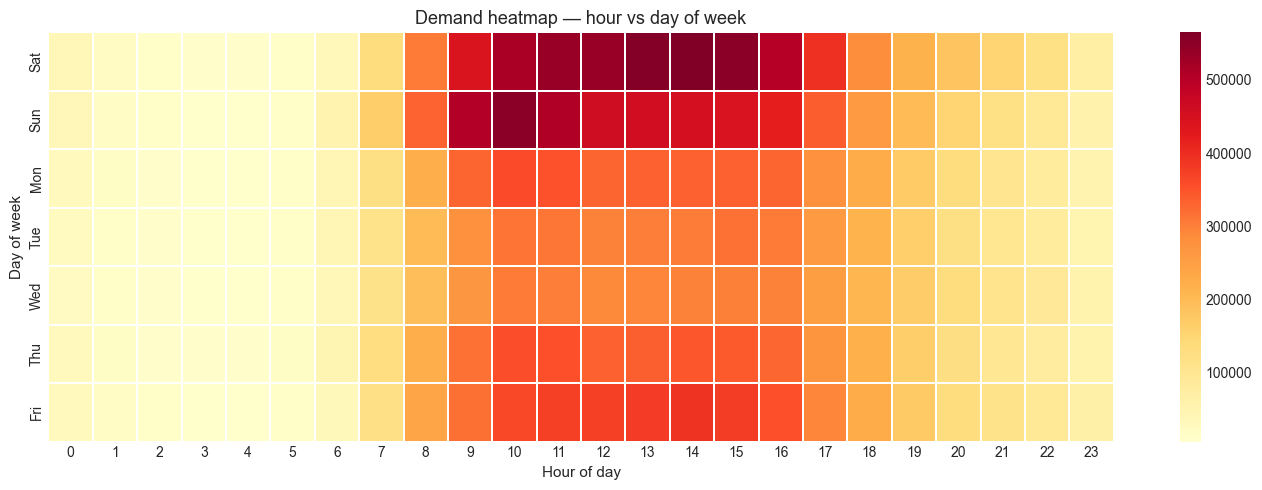

In [25]:
# ── Cell 12 — EDA Plot 5: heatmap hour x day ─────────────────────────
pivot = df.groupby(['order_dow','order_hour_of_day']).size().unstack()
pivot.index = [DAY_NAMES[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            linecolor='white', ax=ax)
ax.set_title('Demand heatmap — hour vs day of week', fontsize=13)
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Day of week', fontsize=11)
plt.tight_layout()
plt.savefig('notebooks/plot_heatmap.png', dpi=150)
plt.show()
print("Save this heatmap screenshot for your GitHub README!")